# 13 — Mamba SSM: v8

## What changes vs TCN v3 / LGBM v7

| # | Problem (previous) | Fix applied here |
|---|---|---|
| 1 | TCN lacks content-based memory gating → collapses to marginal prior | **Mamba selective SSM** — input-dependent A/B/C parameters filter noise dynamically |
| 2 | Transformer O(N²) attention → overfits on small financial datasets | **Mamba O(N)** state-space scan — fixed memory footprint over long sequences |
| 3 | TCN causal conv receptive field limited by depth | **72-hour sequence memory** — full trailing window ingested per prediction |
| 4 | Unfilled limit orders silently discarded, model re-issues immediately | **v8 cooldown fix** — expired limit orders trigger mandatory cooldown = cd_n bars |
| 5 | QT fitted on global train set (cross-fold leakage) | **Per-fold QT** — fit strictly on each fold's training rows |

## Architecture

```
Input (B, 72, F)
  │
  ▼ Linear projection
(B, 72, 128)
  │
  ▼ × 3 Mamba blocks [d_state=16, d_conv=4, expand=2]
    ├── LayerNorm
    ├── in_proj → split → x, z
    ├── Causal depthwise Conv1d (width=4)
    ├── x_proj → dt, B_mat, C_mat
    ├── dt_proj → softplus → delta
    ├── Selective SSM scan: h_t = exp(δA)h_{t-1} + δB·x_t
    ├── y_t = C·h_t + D·x_t
    └── gate: y * silu(z) → residual
  │
  ▼ Final token [:, -1, :]
  ▼ LayerNorm + Dropout
  ▼ Linear(128, 3)
Logits (B, 3)  — CrossEntropy with inverse class-frequency weights
```

## Execution model (v7 Spot/Futures, v8 cooldown fix)

- **Longs (Spot):** limit entry 0% / TP 0% / SL+time 0.05% / Funding 0%
- **Shorts (Futures):** limit entry 0% / TP 0% / SL+time 0.05% / Funding +0.00077%/h received
- **v8 fix:** unfilled limit order (TIF=1 bar) → mandatory cooldown = cd_n bars (blocks re-entry during breakouts)


In [7]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── Mamba architecture ────────────────────────────────────────────────────────
# Reduced vs initial draft: d_model 128->64, layers 3->2, d_state 16->8, seq 72->48
# Rationale: financial SSNs are feature-poor; smaller model generalises better
# and trains ~20x faster (less scan compute + fewer MPS dispatches).
SEQ_LEN        = 48     # hours of trailing memory
D_MODEL        = 64     # Mamba internal model dimension
D_STATE        = 8      # SSM state dimension N (scan cost ∝ N)
D_CONV         = 4      # causal conv kernel width
EXPAND         = 2      # inner dim = D_MODEL * EXPAND = 128
N_MAMBA_LAYERS = 2      # stacked Mamba blocks
DROPOUT        = 0.10
SCAN_CHUNK     = 8      # chunked-scan chunk size: L/SCAN_CHUNK Python iters

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS       = 80
PATIENCE     = 15
BATCH_SIZE   = 512     # larger batch -> fewer MPS dispatches per epoch
LR           = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
SEED         = 42

# ── Purged K-Fold ─────────────────────────────────────────────────────────────
K                    = 5
EMBARGO              = 168    # hours purged around each fold boundary
KFOLD_INTERNAL_VAL_H = 2500   # internal val block size for early stopping

# ── TBM labels (same as v7) ─────────────────────────────────────────────
TBM_ATR_MULT = 2.0    # Class 1=Long (hit close*(1+2*ATR)), Class 0=Short, Class 2=Neutral
TBM_HORIZON  = 24     # max bar lookahead (vertical barrier)

# ── Spot / Futures execution (v7) ───────────────────────────────────────
MAKER_FEE         = 0.0000    # limit entries + TP exits
SPOT_TAKER_FEE    = 0.0005    # Spot SL / time exits (longs)
FUTURES_TAKER_FEE = 0.0005    # Futures SL / time exits (shorts)
BUFFER            = 0.0005    # 5 bp penetration buffer for limit fill
SPOT_FUNDING_H    = 0.0       # Spot longs: zero funding
SHORT_FUNDING_H   = 0.0000077 # Futures shorts: funding received +0.00077%/h

# ── Trading grid ──────────────────────────────────────────────────────────────
TRADING_GRID = {
    'long_threshold':    [0.40, 0.45, 0.50, 0.55],
    'short_threshold':   [0.40, 0.45, 0.50, 0.55],
    'entry_atr_mult':    [0.3, 0.6, 1.0],
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [2.0, 2.5, 3.0],
    'min_sl':            [0.010, 0.015],
    'min_hold':          [4, 8],
    'max_hold':          [24, 48],
    'cooldown':          [2, 3],
}

MIN_TRADES      = 15
OPTIMISE_METRIC = 'sharpe'
TOP_N           = 20


In [8]:
import itertools
import math
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}   Torch: {torch.__version__}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT    : {REPO_ROOT}')
print(f'v8 — Mamba SSM | TBM labels | Spot/Futures routing | v8 cooldown fix')


Device: mps   Torch: 2.11.0
REPO_ROOT    : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
vtrain8 — Mamba SSM | TBM labels | Spot/Futures routing | v8 cooldown fix


In [9]:
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])


def make_tbm_labels(close_arr, high_arr, low_arr, atr_arr, atr_mult=2.0, horizon=24):
    """Triple Barrier Method (identical to v7).
    Class 1: upper barrier close*(1+atr_mult*atr) hit first  -> Long
    Class 0: lower barrier close*(1-atr_mult*atr) hit first  -> Short
    Class 2: time barrier hit first                           -> Neutral
    Last `horizon` rows: label=-1 (dropped, insufficient lookahead).
    """
    N = len(close_arr)
    labels = np.full(N, 2, dtype=np.int8)
    for i in range(N - horizon):
        c     = close_arr[i]
        atr   = atr_arr[i]
        upper = c * (1.0 + atr_mult * atr)
        lower = c * (1.0 - atr_mult * atr)
        for j in range(i + 1, i + horizon + 1):
            if high_arr[j] >= upper:
                labels[i] = 1; break
            elif low_arr[j] <= lower:
                labels[i] = 0; break
    labels[N - horizon:] = -1
    return labels


tbm = make_tbm_labels(
    feat_df['close'].values, feat_df['high'].values,
    feat_df['low'].values,   feat_df['atr_14_pct'].values,
    TBM_ATR_MULT, TBM_HORIZON,
)
feat_df['tbm_label'] = tbm
feat_df = feat_df[feat_df['tbm_label'] >= 0].copy()

# Calendar split
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)
trainval_df = pd.concat([train_df, val_df]).sort_index()

# Feature columns: exclude OHLCV, labels, lookahead cols
_EXCLUDE = {'open', 'high', 'low', 'close', 'volume', 'label', 'tbm_label',
            'return', 'log_return', 'target', 'future_return'}
feature_cols = [
    c for c in feat_df.columns
    if c not in _EXCLUDE
    and not c.startswith('future_')
    and pd.api.types.is_numeric_dtype(feat_df[c])
]

def _arr(df, col): return df[col].values.astype(np.float64)

# TrainVal arrays (for K-Fold)
X_tv       = trainval_df[feature_cols].values.astype(np.float32)
y_tv       = trainval_df['tbm_label'].values.astype(np.int64)
tv_close   = _arr(trainval_df, 'close');  tv_high  = _arr(trainval_df, 'high')
tv_low     = _arr(trainval_df, 'low');    tv_atr   = _arr(trainval_df, 'atr_14_pct')
tv_index   = trainval_df.index

# Test arrays (held out until final evaluation)
X_test     = test_df[feature_cols].values.astype(np.float32)
y_test     = test_df['tbm_label'].values.astype(np.int64)
test_close = _arr(test_df, 'close');   test_high = _arr(test_df, 'high')
test_low   = _arr(test_df, 'low');     test_atr  = _arr(test_df, 'atr_14_pct')
test_index = test_df.index

N_TV = len(trainval_df)
print(f'Features   : {len(feature_cols)}')
for split, df in [('TrainVal', trainval_df), ('Test', test_df)]:
    vc = df['tbm_label'].value_counts().sort_index()
    print(f'{split:8s}: {len(df):>7,} bars | '
          f'Short(0)={vc.get(0, 0):,} ({vc.get(0, 0)/len(df):.1%})  '
          f'Long(1)={vc.get(1, 0):,} ({vc.get(1, 0)/len(df):.1%})  '
          f'Neutral(2)={vc.get(2, 0):,} ({vc.get(2, 0)/len(df):.1%})')
print(f'Sequence length: {SEQ_LEN} hours  |  min training rows per fold: ~{N_TV//K - EMBARGO*2 - KFOLD_INTERNAL_VAL_H:,}')


Features   : 197
TrainVal:  61,118 bars | Short(0)=25,879 (42.3%)  Long(1)=26,013 (42.6%)  Neutral(2)=9,226 (15.1%)
Test    :  13,224 bars | Short(0)=5,762 (43.6%)  Long(1)=5,793 (43.8%)  Neutral(2)=1,669 (12.6%)
Sequence length: 48 hours  |  min training rows per fold: ~9,387


## Phase 1 — Mamba SSM Architecture (Pure PyTorch)

No `mamba-ssm` CUDA kernel dependency — sequential selective scan in pure PyTorch.
Runs on MPS, CUDA, and CPU. The scan is O(L·D·N) which is tractable for L=72, D=256, N=16.

### Selective SSM math

For each channel $d$ and time $t$:

$$h_t^{(d)} = \bar{A}_t^{(d)} \odot h_{t-1}^{(d)} + \bar{B}_t^{(d)} \cdot x_t^{(d)}$$

$$y_t^{(d)} = C_t \cdot h_t^{(d)} + D^{(d)} \cdot x_t^{(d)}$$

where $\bar{A}_t = \exp(\delta_t \odot A)$ and $\bar{B}_t = \delta_t \otimes B_t$ are input-dependent (selective).


In [10]:
def _chunked_ssm_scan(
    x:      "torch.Tensor",  # (B, L, D_inner)
    delta:  "torch.Tensor",  # (B, L, D_inner)  positive timescales
    A:      "torch.Tensor",  # (D_inner, N)       negative definite
    B_mat:  "torch.Tensor",  # (B, L, N)
    C_mat:  "torch.Tensor",  # (B, L, N)
    D_coef: "torch.Tensor",  # (D_inner,)
    chunk:  int = 8,
) -> "torch.Tensor":
    """Chunked vectorized SSM scan — no Python loop over sequence length.

    Replaces the naive sequential Python loop (L Python iters) with
    vectorized within-chunk cumsum + a short sequential carry loop
    over n_chunks = L // chunk Python iterations.

    L=48, chunk=8 → 6 Python iterations instead of 48.

    Math:  h_t = A_bar_t ⊙ h_{t-1} + dB_u_t
           A_bar_t = exp(delta_t ⊙ A),   dB_u_t = delta_t ⊗ B_t ⊙ x_t
           y_t = C_t · h_t + D ⊙ x_t

    Within each chunk the recurrence is solved in closed form via the
    prefix-product identity:
       h_t = P_t ⊙ h_carry + P_t ⊙ cumsum(dBu / P,  dim=time)
    where P_t = ∏_{i=chunk_start}^{t} A_bar_i.

    Numerical note: P_t ∈ (0, 1)^(D,N). With chunk=8 and typical
    softplus(dt_proj) ≈ 0.01–0.1, log_P_chunk ≈ −0.8 to −0.08 per chunk,
    so P_chunk ≈ 0.45–0.92. Division by P is safe in float32.
    """
    B, L, D = x.shape
    N = A.shape[-1]

    # ── Pre-compute dA and dBu for all timesteps at once ────────────────────
    # log_dA[b,t,d,n] = delta[b,t,d] * A[d,n]
    log_dA = delta.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)  # (B, L, D, N)
    # dBu[b,t,d,n] = delta[b,t,d] * B_mat[b,t,n] * x[b,t,d]
    dBu    = delta.unsqueeze(-1) * B_mat.unsqueeze(2) * x.unsqueeze(-1)  # (B, L, D, N)

    # ── Pad to multiple of chunk ─────────────────────────────────────────────
    n_chunks = (L + chunk - 1) // chunk
    L_pad    = n_chunks * chunk
    if L_pad > L:
        pad_len = L_pad - L
        log_dA = F.pad(log_dA, (0, 0, 0, 0, 0, pad_len))
        dBu    = F.pad(dBu,    (0, 0, 0, 0, 0, pad_len))
        C_pad  = F.pad(C_mat,  (0, 0, 0, pad_len))          # (B, L_pad, N)
    else:
        C_pad = C_mat

    # ── Reshape into chunks: (B, n_chunks, chunk, D, N) ─────────────────────
    log_dA_c = log_dA.view(B, n_chunks, chunk, D, N)
    dBu_c    = dBu.view(B, n_chunks, chunk, D, N)
    C_c      = C_pad.view(B, n_chunks, chunk, N)

    # ── Within-chunk vectorized computation ──────────────────────────────────
    # log_P_c[b, k, t, d, n] = sum_{i=0}^{t} log_dA_c[b, k, i, d, n]
    log_P_c = torch.cumsum(log_dA_c, dim=2)        # (B, n_chunks, chunk, D, N)
    P_c     = torch.exp(log_P_c)                   # chunk-local prefix products

    # within-chunk input contribution: P_c * cumsum(dBu / P_c, dim=2)
    dBu_over_P_c = dBu_c / P_c.clamp(min=1e-12)   # safe: P_c >> 1e-12 for chunk=8
    within_c     = P_c * torch.cumsum(dBu_over_P_c, dim=2)  # (B, n_chunks, chunk, D, N)

    # chunk-boundary transition: product over full chunk (B, n_chunks, D, N)
    P_full_c = torch.exp(log_dA_c.sum(dim=2))      # (B, n_chunks, D, N)

    # ── Sequential carry over chunks — only n_chunks Python iters ────────────
    y   = x.new_zeros(B, L_pad, D)
    h   = x.new_zeros(B, D, N)   # carry state, starts at 0
    for ci in range(n_chunks):
        # h_t (within chunk ci) = P_c[ci, t] * h_carry + within_c[ci, t]
        h_in_chunk = (                             # (B, chunk, D, N)
            P_c[:, ci] * h.unsqueeze(1)            # carry contribution
            + within_c[:, ci]                      # within-chunk input
        )
        # y_t = sum_N (h_t * C_t)
        y[:, ci*chunk:(ci+1)*chunk] = (
            h_in_chunk * C_c[:, ci].unsqueeze(-2)  # (B, chunk, D, N)
        ).sum(-1)                                  # (B, chunk, D)
        # Advance carry to end of chunk
        h = P_full_c[:, ci] * h + within_c[:, ci, -1]  # (B, D, N)

    y = y[:, :L]  # remove padding
    return y + x * D_coef.unsqueeze(0).unsqueeze(0)


class MambaBlock(nn.Module):
    """Hardware-agnostic Mamba selective SSM block (Gu & Dao, 2023).

    Uses a chunked vectorized scan instead of a sequential Python loop:
      - L=48, chunk=8  →  6 Python iterations (vs 48 before)
      - Within each chunk: fully vectorized via torch.cumsum
      - Mamba-style dt initialization keeps P_chunk ≈ 0.5–0.9 (numerically safe)

    Architecture per block:
      x (B, L, D) -> norm -> in_proj -> [x_in, z]
      x_in -> causal depthwise Conv1d -> silu -> x_conv
      x_conv -> x_proj -> [dt, B_mat, C_mat]
      dt -> dt_proj -> softplus -> delta  (data-dependent timescale)
      chunked scan: h_t = exp(δ⊗A)*h_{t-1} + δ⊗B*x_t,  y_t = C·h_t + D*x_t
      output = y * silu(z) -> out_proj -> residual
    """

    def __init__(
        self,
        d_model:  int,
        d_state:  int = 8,
        d_conv:   int = 4,
        expand:   int = 2,
        dt_min:   float = 0.001,
        dt_max:   float = 0.1,
        chunk:    int = 8,
    ):
        super().__init__()
        d_inner     = int(d_model * expand)
        dt_rank     = max(1, math.ceil(d_model / 16))
        self.d_inner = d_inner
        self.d_state = d_state
        self.d_conv  = d_conv
        self.dt_rank = dt_rank
        self.chunk   = chunk

        self.norm    = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)

        self.conv1d = nn.Conv1d(
            d_inner, d_inner, kernel_size=d_conv,
            groups=d_inner, padding=d_conv - 1, bias=True,
        )

        self.x_proj  = nn.Linear(d_inner, dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(dt_rank, d_inner, bias=True)

        # A: log-parameterized, negative → ensures dA ∈ (0,1)
        A_init = (
            torch.arange(1, d_state + 1, dtype=torch.float32)
            .unsqueeze(0).expand(d_inner, -1).clone()
        )
        self.A_log = nn.Parameter(torch.log(A_init))
        self.D     = nn.Parameter(torch.ones(d_inner))
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)

        # Mamba-style dt bias init: keeps delta small (0.001–0.1)
        # so P_chunk stays ≈ 0.5–0.9 (safe for numerical stability)
        with torch.no_grad():
            dt_bias = torch.exp(
                torch.rand(d_inner) * (math.log(dt_max) - math.log(dt_min))
                + math.log(dt_min)
            )
            self.dt_proj.bias.copy_(dt_bias + torch.log(-torch.expm1(-dt_bias)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, L, d_model) -> (B, L, d_model)"""
        residual = x
        x = self.norm(x)
        L = x.shape[1]

        xz       = self.in_proj(x)                              # (B, L, 2*d_inner)
        x_in, z  = xz.chunk(2, dim=-1)

        x_conv   = self.conv1d(x_in.transpose(1, 2))[:, :, :L].transpose(1, 2)
        x_conv   = F.silu(x_conv)

        x_dbl    = self.x_proj(x_conv)
        dt       = x_dbl[..., :self.dt_rank]
        B_mat    = x_dbl[..., self.dt_rank : self.dt_rank + self.d_state]
        C_mat    = x_dbl[..., self.dt_rank + self.d_state :]
        delta    = F.softplus(self.dt_proj(dt))                 # (B, L, d_inner)

        A = -torch.exp(self.A_log.float())                      # (d_inner, d_state)
        y = _chunked_ssm_scan(x_conv, delta, A, B_mat, C_mat, self.D, self.chunk)
        y = y * F.silu(z)
        return residual + self.out_proj(y)


class MambaTimeSeriesClassifier(nn.Module):
    """Stack of Mamba blocks for 3-class TBM directional prediction.

    Input  : (batch, seq_len, input_dim)  — quantile-normalized features
    Output : (batch, 3)  — raw logits [Short, Long, Neutral]
    """

    def __init__(
        self,
        input_dim:  int,
        d_model:    int = 64,
        d_state:    int = 8,
        d_conv:     int = 4,
        expand:     int = 2,
        n_layers:   int = 2,
        n_classes:  int = 3,
        dropout:    float = 0.1,
        chunk:      int = 8,
    ):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
        )
        self.mamba_blocks = nn.ModuleList([
            MambaBlock(d_model, d_state=d_state, d_conv=d_conv, expand=expand, chunk=chunk)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)
        self.head       = nn.Linear(d_model, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        for block in self.mamba_blocks:
            x = block(x)
        x = self.final_norm(x[:, -1, :])
        x = self.dropout(x)
        return self.head(x)


# ── Sanity check + timing estimate ───────────────────────────────────────────
import time
_B = 8
_dummy = torch.randn(_B, SEQ_LEN, 50)  # use small feature dim for speed test
_model = MambaTimeSeriesClassifier(
    input_dim=50, d_model=D_MODEL, d_state=D_STATE,
    d_conv=D_CONV, expand=EXPAND, n_layers=N_MAMBA_LAYERS, chunk=SCAN_CHUNK,
)
_out = _model(_dummy)
n_params = sum(p.numel() for p in _model.parameters())
print(f'MambaTimeSeriesClassifier: {n_params:,} parameters')
print(f'Input  : {list(_dummy.shape)}  →  Output : {list(_out.shape)}')
print(f'Scan: chunked (chunk={SCAN_CHUNK}, {SEQ_LEN//SCAN_CHUNK} carries per forward pass)')

# Batch timing on actual device
_model_d = MambaTimeSeriesClassifier(
    input_dim=50, d_model=D_MODEL, d_state=D_STATE,
    d_conv=D_CONV, expand=EXPAND, n_layers=N_MAMBA_LAYERS, chunk=SCAN_CHUNK,
).to(DEVICE)
_dummy_d = torch.randn(BATCH_SIZE, SEQ_LEN, 50).to(DEVICE)
# Warm up
_model_d(_dummy_d)
# Time 5 forward passes
t0 = time.perf_counter()
for _ in range(5):
    _out_d = _model_d(_dummy_d)
ms_fwd = (time.perf_counter() - t0) / 5 * 1000
print(f'Forward ({BATCH_SIZE}×{SEQ_LEN}×50 on {DEVICE}): {ms_fwd:.1f} ms/batch  '
      f'≈ {ms_fwd * 3:.0f} ms/batch w/ backward')
del _dummy, _model, _out, _model_d, _dummy_d, _out_d


MambaTimeSeriesClassifier: 63,107 parameters
Input  : [8, 48, 50]  →  Output : [8, 3]
Scan: chunked (chunk=8, 6 carries per forward pass)
Forward (512×48×50 on mps): 6.2 ms/batch  ≈ 19 ms/batch w/ backward


In [11]:
def build_sequences(X_scaled: np.ndarray, y: np.ndarray,
                     seq_len: int, indices: np.ndarray) -> tuple:
    """Build (N_valid, seq_len, F) sequence tensors from contiguous index set.

    Skips any index where we don't have seq_len history within `indices`.
    Returns (X_seq, y_seq, valid_positions) — valid_positions are row indices
    into the original X_scaled array corresponding to the predicted bar.
    """
    seqs, labels, pos = [], [], []
    idx_set = set(indices.tolist())
    for i, row in enumerate(indices):
        if i < seq_len - 1:
            continue
        # Verify the window [row-seq_len+1, row] is all in indices (contiguous)
        window = indices[i - seq_len + 1 : i + 1]
        if len(window) == seq_len and (window[-1] - window[0]) == seq_len - 1:
            seqs.append(X_scaled[window])
            labels.append(y[row])
            pos.append(row)
    if not seqs:
        return np.empty((0, seq_len, X_scaled.shape[1]), np.float32), np.empty(0, np.int64), []
    return (
        np.stack(seqs, axis=0).astype(np.float32),
        np.array(labels, dtype=np.int64),
        pos,
    )


def compute_class_weights(y: np.ndarray, n_classes: int = 3) -> torch.Tensor:
    """Inverse-frequency class weights for CrossEntropyLoss."""
    counts = np.bincount(y, minlength=n_classes).astype(np.float32)
    counts = np.maximum(counts, 1.0)
    weights = 1.0 / counts
    weights /= weights.sum()
    return torch.tensor(weights * n_classes, dtype=torch.float32)


def score_equity(equity: np.ndarray, trade_df: pd.DataFrame, metric: str) -> float:
    if len(equity) < 2:
        return -999.0
    ret = np.log(np.maximum(equity[1:], 1e-12) / np.maximum(equity[:-1], 1e-12))
    std = ret.std(ddof=1) + 1e-12
    sharpe = ret.mean() / std * np.sqrt(24 * 365)
    total_ret = float(equity[-1] - 1.0)
    pk  = np.maximum.accumulate(equity)
    mdd = float(((equity - pk) / (pk + 1e-12)).min())
    if metric == 'sharpe':
        return sharpe
    elif metric == 'calmar':
        return total_ret / (-mdd + 1e-12)
    return total_ret


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    grad_clip: float = 1.0,
) -> float:
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / max(len(loader.dataset), 1)


@torch.no_grad()
def eval_loss(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        total_loss += criterion(logits, y_batch).item() * len(y_batch)
    return total_loss / max(len(loader.dataset), 1)


@torch.no_grad()
def predict_probs(
    model: nn.Module,
    X_seq: np.ndarray,
    device: torch.device,
    batch_size: int = 512,
) -> np.ndarray:
    """Returns softmax probabilities (N, 3)."""
    model.eval()
    all_probs = []
    dataset = TensorDataset(torch.from_numpy(X_seq))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for (X_b,) in loader:
        logits = model(X_b.to(device))
        all_probs.append(F.softmax(logits, dim=-1).cpu().numpy())
    return np.concatenate(all_probs, axis=0)


print('Training utilities defined.')
print(f'  build_sequences | compute_class_weights | score_equity')
print(f'  train_one_epoch | eval_loss | predict_probs')


Training utilities defined.
  build_sequences | compute_class_weights | score_equity
  train_one_epoch | eval_loss | predict_probs


## Phase 2 — Purged K-Fold Cross-Validation

- **5 folds** over the TrainVal period (2017–2024)
- **168-hour embargo** on both sides of each fold boundary (eliminates sequence indicator leakage)
- **2,500-hour internal val block** immediately preceding the embargo — controls early stopping
- **Per-fold QuantileTransformer** fitted strictly on each fold's training rows
- OOS probabilities are cached for all 3 classes across the full TrainVal period


In [12]:
oos_probs_tv = np.full((N_TV, 3), np.nan, dtype=np.float32)
fold_size    = N_TV // K
print(f'K={K}  fold_size≈{fold_size:,}  EMBARGO={EMBARGO}  INT_VAL={KFOLD_INTERNAL_VAL_H}')

for fold_k in range(K):
    print(f'\n{"="*65}')
    fold_start = fold_k * fold_size
    fold_end   = (fold_k + 1) * fold_size if fold_k < K - 1 else N_TV
    emb_start  = max(0,    fold_start - EMBARGO)
    emb_end    = min(N_TV, fold_end   + EMBARGO)
    print(f'Fold {fold_k+1}/{K}: rows [{fold_start},{fold_end})  embargo [{emb_start},{emb_end})')

    # ── Internal val: 2500h block immediately before embargo ─────────────────
    if emb_start >= KFOLD_INTERNAL_VAL_H + SEQ_LEN:
        int_end   = emb_start
        int_start = max(SEQ_LEN, emb_start - KFOLD_INTERNAL_VAL_H)
        int_src   = f'pre-fold [{int_start},{int_end})'
    else:
        int_start = min(emb_end, N_TV - KFOLD_INTERNAL_VAL_H)
        int_start = max(SEQ_LEN, int_start)
        int_end   = min(N_TV, int_start + KFOLD_INTERNAL_VAL_H)
        int_src   = f'post-emb [{int_start},{int_end})'
    n_int = int_end - int_start
    print(f'  Int val: {int_src} ({n_int} rows)')

    # ── Training rows (exclude fold, embargo, internal val) ──────────────────
    train_mask = np.ones(N_TV, dtype=bool)
    train_mask[emb_start:emb_end] = False
    train_mask[int_start:int_end] = False
    train_indices = np.where(train_mask)[0]

    # ── Per-fold QuantileTransformer fitted strictly on training rows ─────────
    qt_fold = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                                   random_state=SEED)
    qt_fold.fit(X_tv[train_indices])
    X_scaled = qt_fold.transform(X_tv)  # transform full TrainVal for sequence building

    # ── Build training sequences (contiguous segments only) ──────────────────
    # Identify contiguous segments within train_indices
    gaps = np.where(np.diff(train_indices) > 1)[0]
    seg_bounds = [(0, len(train_indices))]
    if len(gaps):
        seg_bounds = []
        prev = 0
        for g in gaps:
            seg_bounds.append((prev, g + 1))
            prev = g + 1
        seg_bounds.append((prev, len(train_indices)))

    tr_seqs, tr_labs = [], []
    for sb, se in seg_bounds:
        seg_idx = train_indices[sb:se]
        Xs, ys, _ = build_sequences(X_scaled, y_tv, SEQ_LEN, seg_idx)
        if len(Xs):
            tr_seqs.append(Xs); tr_labs.append(ys)

    if not tr_seqs:
        print(f'  WARNING: no training sequences — skipping fold'); continue

    X_tr = np.concatenate(tr_seqs, axis=0)
    y_tr = np.concatenate(tr_labs, axis=0)
    print(f'  Train seqs : {len(X_tr):,}')

    # ── Internal val sequences ───────────────────────────────────────────────
    val_idx = np.arange(int_start, int_end)
    X_vl_seq, y_vl_seq, _ = build_sequences(X_scaled, y_tv, SEQ_LEN, val_idx)
    print(f'  Val seqs   : {len(X_vl_seq):,}')
    if len(X_vl_seq) == 0:
        print('  WARNING: empty val set — skipping fold'); continue

    # ── Class weights ─────────────────────────────────────────────────────────
    cw = compute_class_weights(y_tr).to(DEVICE)

    # ── Model + optimiser ─────────────────────────────────────────────────────
    model = MambaTimeSeriesClassifier(
        input_dim=X_tr.shape[2], d_model=D_MODEL, d_state=D_STATE,
        d_conv=D_CONV, expand=EXPAND, n_layers=N_MAMBA_LAYERS, dropout=DROPOUT,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(weight=cw)

    tr_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    vl_ds = TensorDataset(torch.from_numpy(X_vl_seq), torch.from_numpy(y_vl_seq))
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    vl_ld = DataLoader(vl_ds, batch_size=512,        shuffle=False)

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    pbar = tqdm(range(EPOCHS), desc=f'  Fold {fold_k+1} training', ncols=80, leave=False)
    for epoch in pbar:
        tr_loss = train_one_epoch(model, tr_ld, optimizer, criterion, DEVICE, GRAD_CLIP)
        vl_loss = eval_loss(model, vl_ld, criterion, DEVICE)
        scheduler.step()

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        pbar.set_postfix({'tr': f'{tr_loss:.4f}', 'vl': f'{vl_loss:.4f}',
                          'pat': patience_count})
        if patience_count >= PATIENCE:
            print(f'\n  Early stop at epoch {epoch+1}')
            break

    # ── OOS inference on fold rows ────────────────────────────────────────────
    model.load_state_dict(best_state)
    fold_idx     = np.arange(fold_start, fold_end)
    X_fold_seq, _, fold_pos = build_sequences(X_scaled, y_tv, SEQ_LEN, fold_idx)

    if len(X_fold_seq):
        fold_probs = predict_probs(model, X_fold_seq, DEVICE)
        for pi, row in enumerate(fold_pos):
            oos_probs_tv[row] = fold_probs[pi]
        print(f'  OOS probs  : {len(fold_pos):,} rows  |  best_val_loss={best_val_loss:.4f}')
    else:
        print(f'  WARNING: no OOS sequences for fold {fold_k+1}')

    del model, best_state, tr_seqs, tr_labs

print('\nK-Fold complete.')
valid_mask = np.isfinite(oos_probs_tv[:, 0])
print(f'Valid OOS rows: {valid_mask.sum():,} / {N_TV:,} '
      f'({valid_mask.mean():.1%})')


K=5  fold_size≈12,223  EMBARGO=168  INT_VAL=2500

Fold 1/5: rows [0,12223)  embargo [0,12391)
  Int val: post-emb [12391,14891) (2500 rows)
  Train seqs : 46,180
  Val seqs   : 2,453



  Early stop at epoch 16
  OOS probs  : 12,176 rows  |  best_val_loss=1.0589

Fold 2/5: rows [12223,24446)  embargo [12055,24614)
  Int val: pre-fold [9555,12055) (2500 rows)
  Train seqs : 45,965
  Val seqs   : 2,453



  Early stop at epoch 17
  OOS probs  : 12,176 rows  |  best_val_loss=1.0697

Fold 3/5: rows [24446,36669)  embargo [24278,36837)
  Int val: pre-fold [21778,24278) (2500 rows)
  Train seqs : 45,965
  Val seqs   : 2,453



  Early stop at epoch 16
  OOS probs  : 12,176 rows  |  best_val_loss=1.0049

Fold 4/5: rows [36669,48892)  embargo [36501,49060)
  Int val: pre-fold [34001,36501) (2500 rows)
  Train seqs : 45,965
  Val seqs   : 2,453



  Early stop at epoch 17
  OOS probs  : 12,176 rows  |  best_val_loss=0.9801

Fold 5/5: rows [48892,61118)  embargo [48724,61118)
  Int val: pre-fold [46224,48724) (2500 rows)
  Train seqs : 46,177
  Val seqs   : 2,453



  Early stop at epoch 16
  OOS probs  : 12,179 rows  |  best_val_loss=1.0449

K-Fold complete.
Valid OOS rows: 60,883 / 61,118 (99.6%)


OOS AUC_Long  : 0.5572
OOS AUC_Short : 0.5687
P(Long)   mean=0.3478  std=0.1105
P(Short)  mean=0.3589  std=0.1191
P(Neutral)mean=0.2934  std=0.1975


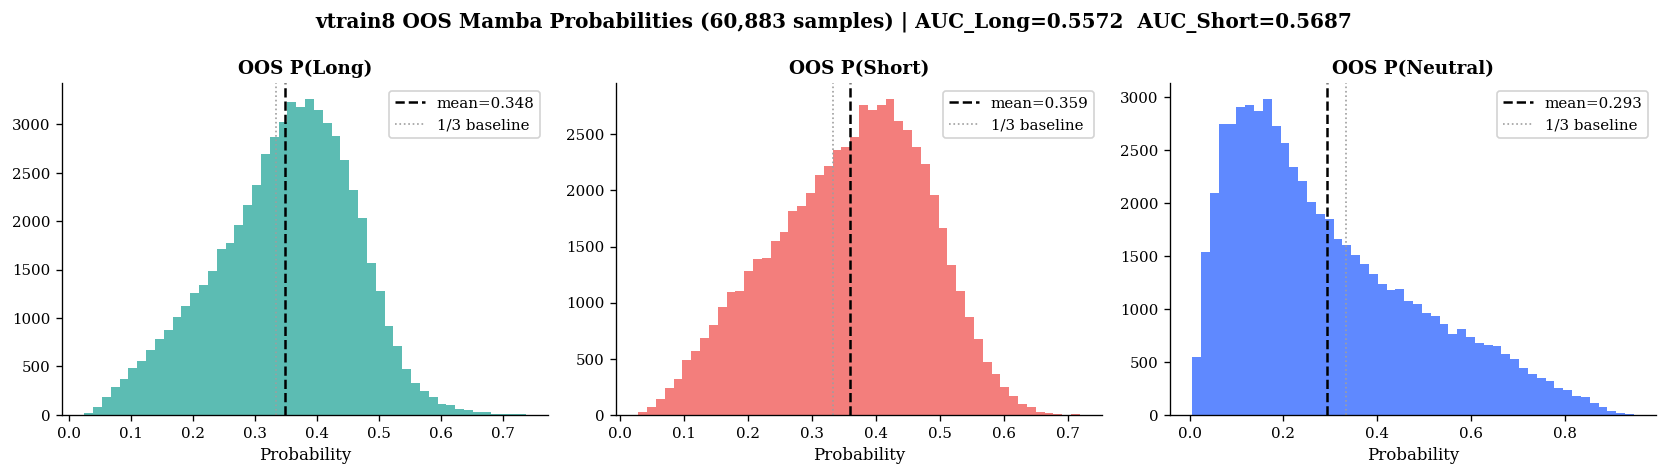

In [13]:
valid_mask = np.isfinite(oos_probs_tv[:, 0])
p_up_oos   = oos_probs_tv[valid_mask, 1].astype(np.float64)   # P(Long)
p_dn_oos   = oos_probs_tv[valid_mask, 0].astype(np.float64)   # P(Short)
p_nu_oos   = oos_probs_tv[valid_mask, 2].astype(np.float64)   # P(Neutral)
oos_y_tv   = y_tv[valid_mask]

c_oos = tv_close[valid_mask]; h_oos = tv_high[valid_mask]
l_oos = tv_low[valid_mask];   a_oos = tv_atr[valid_mask]
idx_oos = tv_index[valid_mask]

# AUC
auc_long  = roc_auc_score((oos_y_tv == 1).astype(int), p_up_oos)
auc_short = roc_auc_score((oos_y_tv == 0).astype(int), p_dn_oos)
print(f'OOS AUC_Long  : {auc_long:.4f}')
print(f'OOS AUC_Short : {auc_short:.4f}')
print(f'P(Long)   mean={p_up_oos.mean():.4f}  std={p_up_oos.std():.4f}')
print(f'P(Short)  mean={p_dn_oos.mean():.4f}  std={p_dn_oos.std():.4f}')
print(f'P(Neutral)mean={p_nu_oos.mean():.4f}  std={p_nu_oos.std():.4f}')

# Prob distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, prob, label, color in [
    (axes[0], p_up_oos, 'OOS P(Long)',    GREEN),
    (axes[1], p_dn_oos, 'OOS P(Short)',   RED),
    (axes[2], p_nu_oos, 'OOS P(Neutral)', BLUE),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5, label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3 baseline')
    ax.set_xlabel('Probability'); ax.legend()
    ax.set_title(label, fontweight='bold')
fig.suptitle(
    f'v8 OOS Mamba Probabilities ({len(p_up_oos):,} samples) | '
    f'AUC_Long={auc_long:.4f}  AUC_Short={auc_short:.4f}',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'mamba_oos_prob_distribution.png'); plt.show()


## Phase 3 — Trading Engine: `run_backtest_v8`

### Changes vs v7

| Fix | v7 | v8 |
|---|---|---|
| Unfilled order cooldown | Expired limit → `n_expires += 1` only | Expired limit → `cooldown = cd_n` mandatory pause |

The unfilled-order cooldown prevents the engine from re-issuing limit orders every bar during a fast directional breakout where the price never retraces to the limit level.

### Spot / Futures routing (unchanged from v7)

- **Longs (Spot):** limit entry 0% / TP 0% / SL+time 0.05% / Funding 0%/h
- **Shorts (Futures):** limit entry 0% / TP 0% / SL+time 0.05% / Funding +0.00077%/h received
- **Both-hit pessimism:** if TP and SL both penetrated in same bar → SL wins


In [14]:
def run_backtest_v8(
    p_up, p_down, close_arr, high_arr, low_arr, atr_arr, params,
    spot_taker=SPOT_TAKER_FEE, fut_taker=FUTURES_TAKER_FEE,
    maker_fee=MAKER_FEE, buf=BUFFER,
    spot_fund=SPOT_FUNDING_H, short_fund=SHORT_FUNDING_H,
):
    """Spot/Futures backtester with v8 unfilled-order cooldown fix.

    Longs  (Spot)   : 0% entry/TP | spot_taker on SL/time | zero funding
    Shorts (Futures): 0% entry/TP | fut_taker on SL/time  | funding RECEIVED
    Pessimistic both-hit: SL wins if both barriers crossed in same bar.
    v8 fix: expired (unfilled) limit order -> mandatory cooldown = cd_n bars.
    """
    lt         = params['long_threshold']
    st         = params['short_threshold']
    exit_long  = 1.0 - lt    # confidence-exit threshold for longs
    exit_short = 1.0 - st    # confidence-exit threshold for shorts
    ent_atr    = params['entry_atr_mult']
    sl_m       = params['sl_atr_multiplier']
    tp_m       = params['tp_atr_multiplier']
    min_sl     = params['min_sl']
    min_hold   = int(params['min_hold'])
    max_hold   = int(params['max_hold'])
    cd_n       = int(params['cooldown'])

    cash = 1.0; units = 0.0; entry_cash = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; dynamic_sl = 0.0; dynamic_tp = 0.0
    hold_count = 0; cooldown = 0; entry_bar = -1
    pending = None

    equity_curve = [1.0]
    trade_log    = []
    n_signals = 0; n_fills = 0; n_expires = 0

    N = len(close_arr)
    for i in range(N):
        px  = close_arr[i]; hi = high_arr[i]; lo = low_arr[i]
        pup = p_up[i];      pdn = p_down[i];  atr = atr_arr[i]
        if cooldown > 0:
            cooldown -= 1

        # ── 1. Fill / expire pending limit order (TIF = 1 bar) ───────────────
        if pending is not None:
            lp = pending['limit_px']
            if pending['direction'] == 'long':
                if lo < lp * (1.0 - buf):
                    units      = cash * (1.0 - maker_fee) / lp
                    cash       = 0.0; in_pos = True; direction = 'long'
                    entry_px   = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    n_fills   += 1
                else:
                    n_expires += 1
                    cooldown   = cd_n   # v8: unfilled → mandatory cooldown
            else:  # short
                if hi > lp * (1.0 + buf):
                    entry_cash = cash * (1.0 - maker_fee)
                    cash       = 0.0; units = entry_cash / lp
                    in_pos     = True; direction = 'short'
                    entry_px   = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    n_fills   += 1
                else:
                    n_expires += 1
                    cooldown   = cd_n   # v8: unfilled → mandatory cooldown
            pending = None

        # ── 2. Manage open position ───────────────────────────────────────────
        if in_pos and i > entry_bar:
            hold_count += 1
            if direction == 'long':
                units *= (1.0 - spot_fund)       # Spot: zero drag (spot_fund=0)
            else:
                entry_cash *= (1.0 + short_fund) # Futures: funding received

            # Mark-to-market equity
            if direction == 'long':
                equity_curve.append(units * px + cash)
            else:
                mtm_pnl = entry_cash * (entry_px / px - 1.0)
                equity_curve.append(cash + entry_cash + mtm_pnl)

            hit_sl = (direction == 'long'  and lo <= dynamic_sl) or                      (direction == 'short' and hi >= dynamic_sl)
            hit_tp = (direction == 'long'  and hi >= dynamic_tp) or                      (direction == 'short' and lo <= dynamic_tp)
            conf_exit = (hold_count >= min_hold and
                         ((direction == 'long'  and pup < exit_long) or
                          (direction == 'short' and pdn < exit_short)))
            time_exit = (hold_count >= max_hold)

            close_pos = hit_sl or hit_tp or conf_exit or time_exit

            if close_pos:
                if hit_sl or (hit_sl and hit_tp):   # pessimistic: SL wins on both-hit
                    exit_px = dynamic_sl
                    reason  = 'sl'
                    fee     = spot_taker if direction == 'long' else fut_taker
                elif hit_tp:
                    exit_px = dynamic_tp
                    reason  = 'tp'
                    fee     = maker_fee
                else:
                    exit_px = px
                    reason  = 'conf' if conf_exit else 'time'
                    fee     = spot_taker if direction == 'long' else fut_taker

                if direction == 'long':
                    proceeds = units * exit_px * (1.0 - fee)
                    pnl_pct  = (exit_px * (1.0 - fee) / entry_px) - 1.0
                    cash     = proceeds
                else:
                    pnl_frac = (entry_px / exit_px - 1.0) * (1.0 - fee)
                    pnl_pct  = pnl_frac
                    cash     = entry_cash * (1.0 + pnl_frac)

                equity_curve[-1] = cash
                trade_log.append({
                    'entry_bar': entry_bar, 'exit_bar': i,
                    'direction': direction, 'entry_px': entry_px,
                    'exit_px': exit_px, 'pnl_pct': pnl_pct, 'reason': reason,
                })
                in_pos = False; direction = None; units = 0.0
                entry_cash = 0.0; cooldown = cd_n
        else:
            if not in_pos:
                equity_curve.append(cash)

        # ── 3. New signal (only when flat and not in cooldown) ────────────────
        if not in_pos and cooldown == 0 and pending is None:
            sl_raw = max(min_sl, sl_m * atr)
            tp_raw = tp_m * atr

            if pup >= lt:   # Long signal
                n_signals += 1
                lim_px     = px * (1.0 - ent_atr * atr)
                pending    = {
                    'direction': 'long',
                    'limit_px':  lim_px,
                    'sl': lim_px * (1.0 - sl_raw),
                    'tp': lim_px * (1.0 + tp_raw),
                }
            elif pdn >= st: # Short signal
                n_signals += 1
                lim_px     = px * (1.0 + ent_atr * atr)
                pending    = {
                    'direction': 'short',
                    'limit_px':  lim_px,
                    'sl': lim_px * (1.0 + sl_raw),
                    'tp': lim_px * (1.0 - tp_raw),
                }

    eq = np.array(equity_curve, dtype=np.float64)
    tdf = pd.DataFrame(trade_log)
    tdf.attrs['n_signals'] = n_signals
    tdf.attrs['n_fills']   = n_fills
    tdf.attrs['n_expires'] = n_expires
    return eq, tdf


print('run_backtest_v8 defined.')
print('  v8 fix: expired limit order -> cooldown = cd_n (blocks immediate re-entry)')
print('  Spot longs: 0% funding  |  Futures shorts: +0.00077%/h received')


run_backtest_v8 defined.
  v8 fix: expired limit order -> cooldown = cd_n (blocks immediate re-entry)
  Spot longs: 0% funding  |  Futures shorts: +0.00077%/h received


In [15]:
import time

trading_keys   = list(TRADING_GRID.keys())
trading_combos = list(itertools.product(*[TRADING_GRID[k] for k in trading_keys]))
valid_trading  = [
    dict(zip(trading_keys, v)) for v in trading_combos
    if v[0] >= 0.40 and v[1] >= 0.40   # both thresholds above random baseline (1/3)
]
print(f'Trading combinations: {len(valid_trading):,}')

results = []
t0 = time.perf_counter()
for tp in tqdm(valid_trading, desc='Grid search (OOS Mamba)', ncols=80):
    eq, tdf = run_backtest_v8(p_up_oos, p_dn_oos, c_oos, h_oos, l_oos, a_oos, tp)
    if len(tdf) < MIN_TRADES:
        continue

    s  = score_equity(eq, tdf, OPTIMISE_METRIC)
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    fr  = tdf.attrs['n_fills'] / max(tdf.attrs['n_signals'], 1)
    results.append({
        **tp,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
        'max_dd':       float(((eq - pk) / (pk + 1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()) if len(tdf) else 0.0,
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
        'fill_rate':    fr,
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nElapsed: {time.perf_counter()-t0:.1f}s')
print(f'Valid configs (≥{MIN_TRADES} trades): {len(results_df):,} / {len(valid_trading):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}: {results_df["score"].iloc[0]:.4f}')
    print(f'Fill rate:  mean={results_df["fill_rate"].mean():.1%}')


Trading combinations: 6,912


Grid search (OOS Mamba): 100%|██████████████| 6912/6912 [02:29<00:00, 46.11it/s]


Elapsed: 149.9s
Valid configs (≥15 trades): 6,912 / 6,912
Best sharpe: 0.6020
Fill rate:  mean=30.3%


In [16]:
from IPython.display import display

disp_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate', 'fill_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp', 'n_conf',
    'long_threshold', 'short_threshold', 'entry_atr_mult',
    'sl_atr_multiplier', 'tp_atr_multiplier', 'min_sl', 'min_hold', 'max_hold', 'cooldown',
]
top = results_df[disp_cols].head(TOP_N).copy()
for col, fmt in [
    ('total_return', '{:+.2%}'), ('max_dd', '{:.2%}'),
    ('win_rate', '{:.1%}'),      ('fill_rate', '{:.1%}'),
    ('score', '{:.4f}'),         ('sharpe', '{:.3f}'),
]:
    top[col] = top[col].map(fmt.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in trading_keys}

print(f'Top {TOP_N} configurations by {OPTIMISE_METRIC}  (v8 Mamba):\n')
display(top)
print(f'\n── Best trading params ────────────────────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"Trades":<24}: {int(best["n_trades"])}  (fill rate: {best["fill_rate"]:.1%})')
print(f'  {"Win rate":<24}: {best["win_rate"]:.1%}')
print(f'  {"Long / Short":<24}: {int(best["n_long"])} / {int(best["n_short"])}')
print(f'  {"TP / SL / Conf":<24}: {int(best["n_tp"])} / {int(best["n_sl"])} / {int(best["n_conf"])}')


Top 20 configurations by sharpe  (vtrain8 Mamba):



,score,total_return,sharpe,max_dd,win_rate,fill_rate,n_trades,n_long,n_short,n_sl,...,n_conf,long_threshold,short_threshold,entry_atr_mult,sl_atr_multiplier,tp_atr_multiplier,min_sl,min_hold,max_hold,cooldown
0,0.6020,+130.62%,0.602,-46.38%,47.7%,53.0%,1061,189,872,331,...,448,0.55,0.50,0.3,1.5,3.0,0.015,8,48,2
1,0.5610,+103.60%,0.561,-39.82%,44.2%,53.2%,1213,208,1005,398,...,580,0.55,0.50,0.3,1.5,3.0,0.010,4,24,2
2,0.5563,+115.85%,0.556,-48.13%,47.3%,52.8%,1075,196,879,332,...,436,0.55,0.50,0.3,1.5,3.0,0.015,8,24,2
3,0.5552,+111.06%,0.555,-48.61%,44.3%,53.0%,1104,199,905,470,...,361,0.55,0.50,0.3,1.5,3.0,0.010,8,48,2
4,0.5491,+108.74%,0.549,-47.53%,44.3%,52.7%,1114,204,910,466,...,358,0.55,0.50,0.3,1.5,3.0,0.010,8,24,2
5,0.5371,+97.76%,0.537,-40.05%,44.0%,53.3%,1204,205,999,404,...,581,0.55,0.50,0.3,1.5,3.0,0.010,4,48,2
6,0.5337,+141.94%,0.534,-49.29%,48.9%,51.5%,2054,195,1859,779,...,577,0.55,0.45,0.3,1.5,2.0,0.010,8,48,2
7,0.5313,+113.62%,0.531,-45.80%,48.7%,53.2%,1052,188,864,298,...,473,0.55,0.50,0.3,2.0,3.0,0.015,8,48,2
8,0.5303,+61.39%,0.530,-17.62%,44.6%,50.0%,504,194,310,211,...,125,0.55,0.55,0.3,1.5,3.0,0.010,4,24,3
9,0.5303,+89.96%,0.530,-40.30%,44.9%,53.3%,1239,217,1022,402,...,526,0.55,0.50,0.3,1.5,2.5,0.010,4,24,2



── Best trading params ────────────────────────────────────────────────
  long_threshold          : 0.55
  short_threshold         : 0.5
  entry_atr_mult          : 0.3
  sl_atr_multiplier       : 1.5
  tp_atr_multiplier       : 3.0
  min_sl                  : 0.015
  min_hold                : 8.0
  max_hold                : 48.0
  cooldown                : 2.0
  OOS Sharpe              : 0.6020
  OOS Return              : +130.62%
  OOS MaxDD               : -46.38%
  Trades                  : 1061  (fill rate: 53.0%)
  Win rate                : 47.7%
  Long / Short            : 189 / 872
  TP / SL / Conf          : 281 / 331 / 448


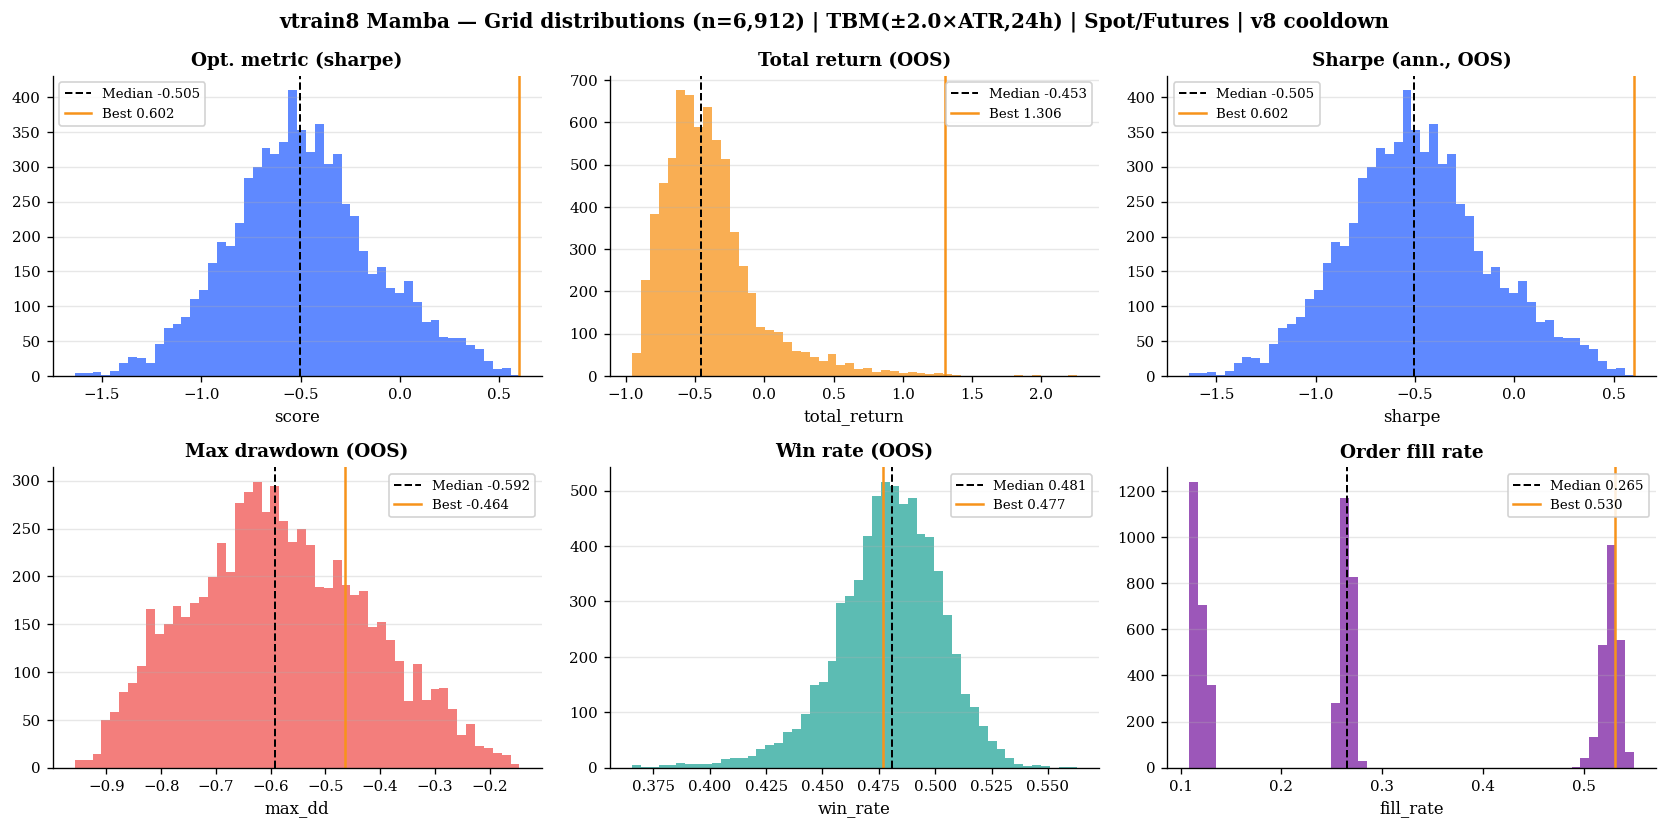

In [17]:
if not results_df.empty:
    plot_cols = [
        ('score',        f'Opt. metric ({OPTIMISE_METRIC})', BLUE),
        ('total_return', 'Total return (OOS)',               ACCENT),
        ('sharpe',       'Sharpe (ann., OOS)',               BLUE),
        ('max_dd',       'Max drawdown (OOS)',               RED),
        ('win_rate',     'Win rate (OOS)',                   GREEN),
        ('fill_rate',    'Order fill rate',                  PURPLE),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (col, title, color) in zip(axes.flat, plot_cols):
        data = results_df[col]
        ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(data.median(), color='black', lw=1.2, ls='--',
                   label=f'Median {data.median():.3f}')
        ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5,
                   label=f'Best {results_df[col].iloc[0]:.3f}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    fig.suptitle(
        f'v8 Mamba — Grid distributions (n={len(results_df):,}) | '
        f'TBM(±{TBM_ATR_MULT}×ATR,{TBM_HORIZON}h) | Spot/Futures | v8 cooldown',
        fontweight='bold',
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'mamba_grid_distributions.png'); plt.show()


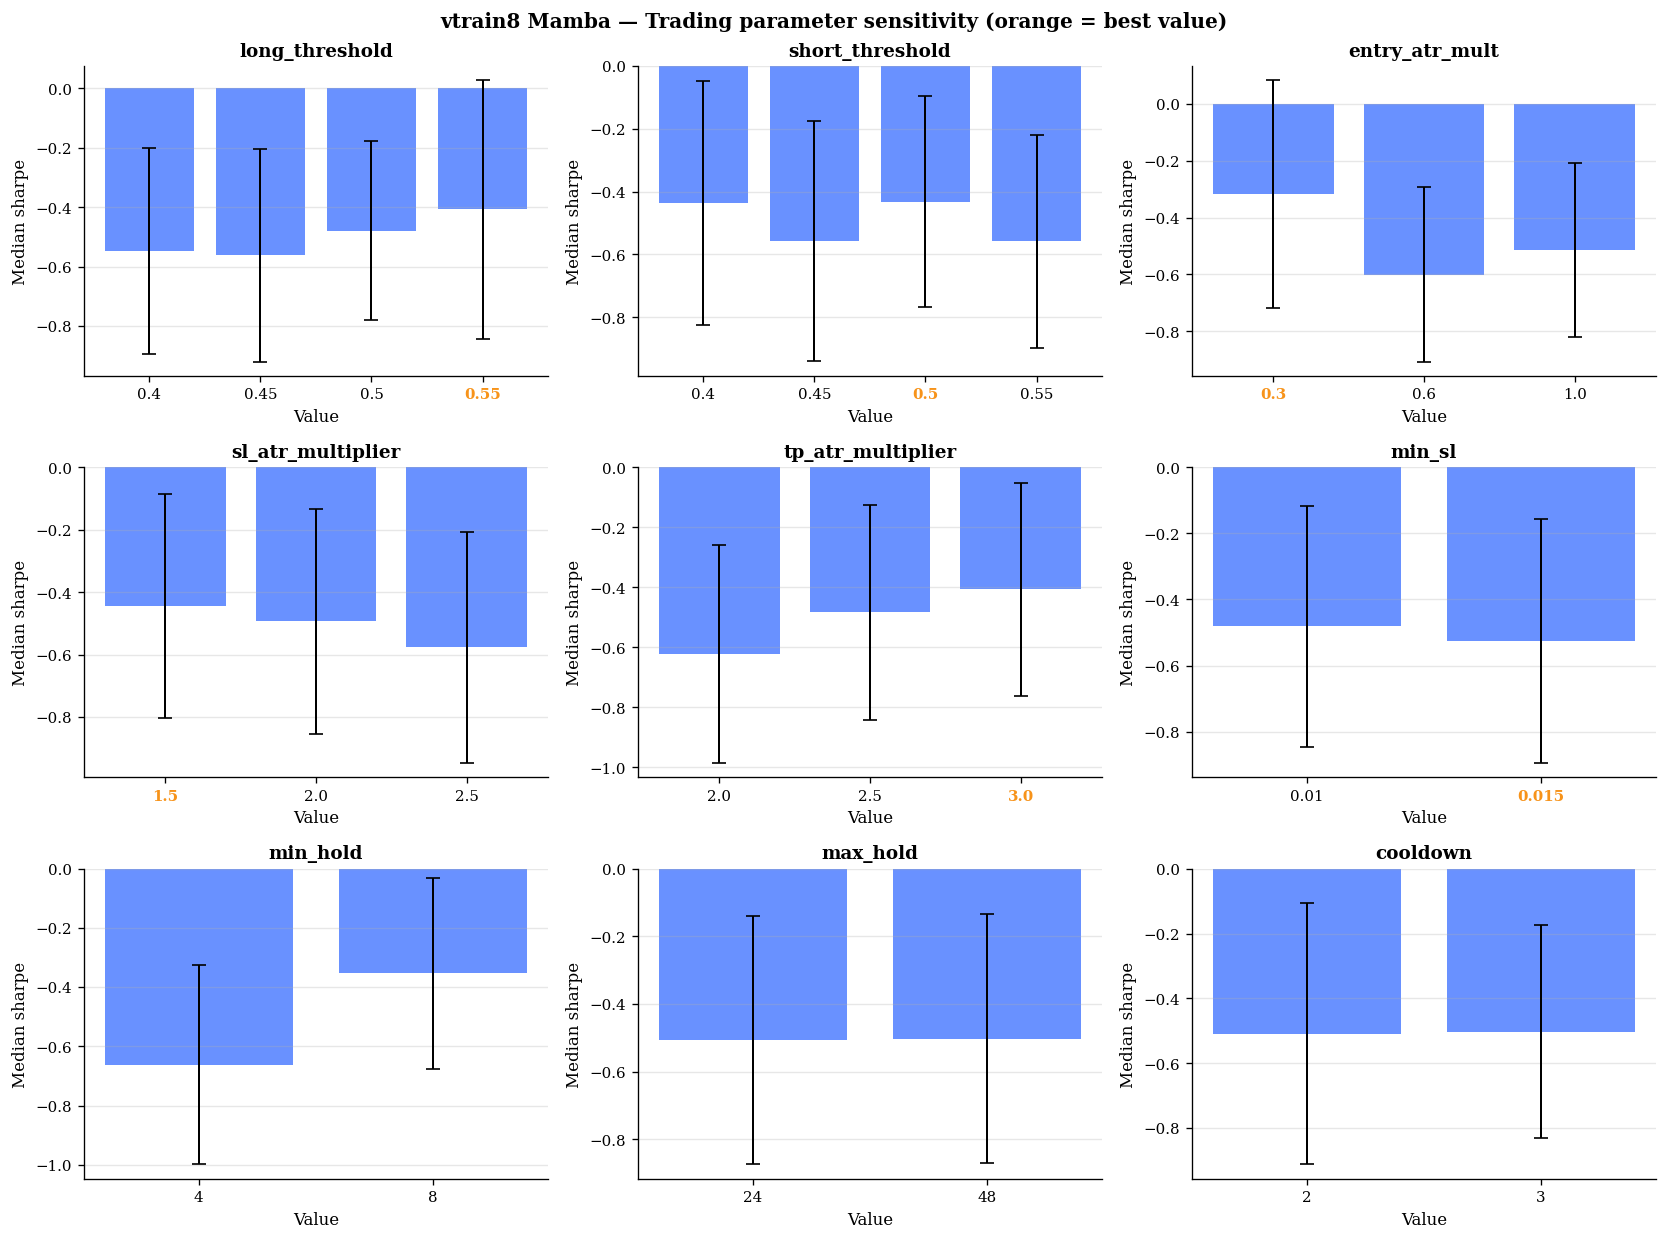

In [18]:
if not results_df.empty:
    n_p = len(trading_keys); ncols = 3; nrows = int(np.ceil(n_p / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    for ax, param in zip(axes.flat, trading_keys):
        grp = results_df.groupby(param)['score'].agg(['median', 'std']).reset_index()
        x   = grp[param].astype(str)
        ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
        ax.errorbar(x, grp['median'], yerr=grp['std'],
                    fmt='none', color='black', capsize=4, lw=1.2)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
        ax.grid(axis='y', alpha=0.3)
        bv = str(best[param])
        for tick in ax.get_xticklabels():
            if tick.get_text() == bv:
                tick.set_color(ACCENT); tick.set_fontweight('bold')
    for ax in axes.flat[n_p:]:
        ax.set_visible(False)
    fig.suptitle(
        'v8 Mamba — Trading parameter sensitivity (orange = best value)',
        fontweight='bold',
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'mamba_grid_sensitivity.png'); plt.show()


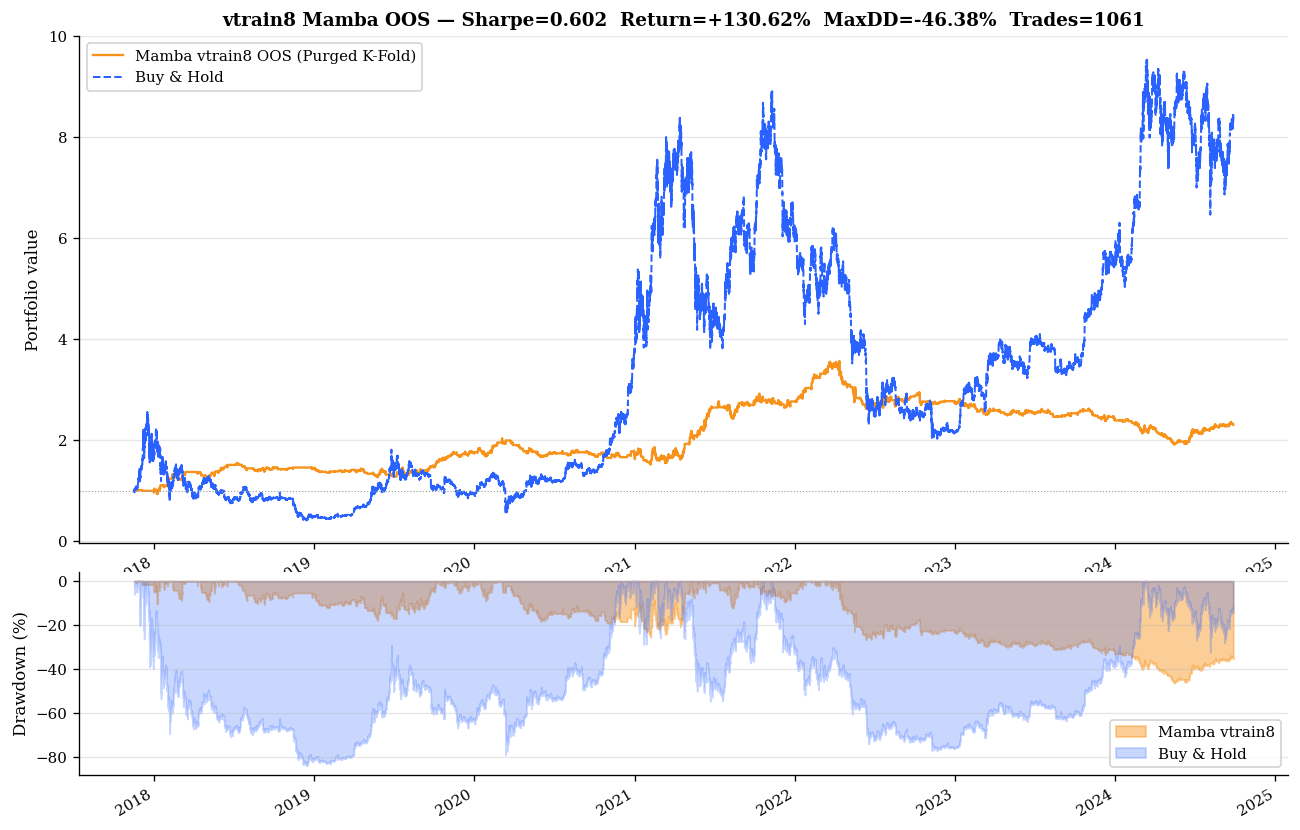

OOS | Sharpe=0.602  Return=+130.62%  MaxDD=-46.38%  Trades=1061  Fill=53.0%  WR=47.7%
     Long=189  Short=872  TP=281  SL=331  Conf=448  Time=1


In [19]:
eq_oos, tdf_oos = run_backtest_v8(
    p_up_oos, p_dn_oos, c_oos, h_oos, l_oos, a_oos, best_params,
)
bh_oos  = c_oos / c_oos[0]
min_len = min(len(idx_oos), len(eq_oos), len(bh_oos))
oos_dt  = idx_oos[:min_len]
eq_oos  = eq_oos[:min_len]
bh_oos  = bh_oos[:min_len]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(oos_dt, eq_oos, color=ACCENT, lw=1.4, label='Mamba v8 OOS (Purged K-Fold)')
ax.plot(oos_dt, bh_oos, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value'); ax.legend(); ax.grid(axis='y', alpha=0.3)

ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
sharpe  = ret_oos.mean() / (ret_oos.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)
mdd     = ((eq_oos - pk_oos) / (pk_oos + 1e-12)).min()
ax.set_title(
    f'v8 Mamba OOS — Sharpe={sharpe:.3f}  Return={eq_oos[-1]-1:+.2%}  '
    f'MaxDD={mdd:.2%}  Trades={len(tdf_oos)}',
    fontweight='bold',
)

ax = axes[1]
pk_b = np.maximum.accumulate(bh_oos)
ax.fill_between(oos_dt, (eq_oos - pk_oos) / (pk_oos + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Mamba v8')
ax.fill_between(oos_dt, (bh_oos - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'mamba_oos_equity.png'); plt.show()

if len(tdf_oos):
    fr = tdf_oos.attrs['n_fills'] / max(tdf_oos.attrs['n_signals'], 1)
    print(f'OOS | Sharpe={sharpe:.3f}  Return={eq_oos[-1]-1:+.2%}  MaxDD={mdd:.2%}  '
          f'Trades={len(tdf_oos)}  Fill={fr:.1%}  WR={(tdf_oos["pnl_pct"]>0).mean():.1%}')
    print(f'     Long={int((tdf_oos["direction"]=="long").sum())}  '
          f'Short={int((tdf_oos["direction"]=="short").sum())}  '
          f'TP={int((tdf_oos["reason"]=="tp").sum())}  '
          f'SL={int((tdf_oos["reason"]=="sl").sum())}  '
          f'Conf={int((tdf_oos["reason"]=="conf").sum())}  '
          f'Time={int((tdf_oos["reason"]=="time").sum())}')


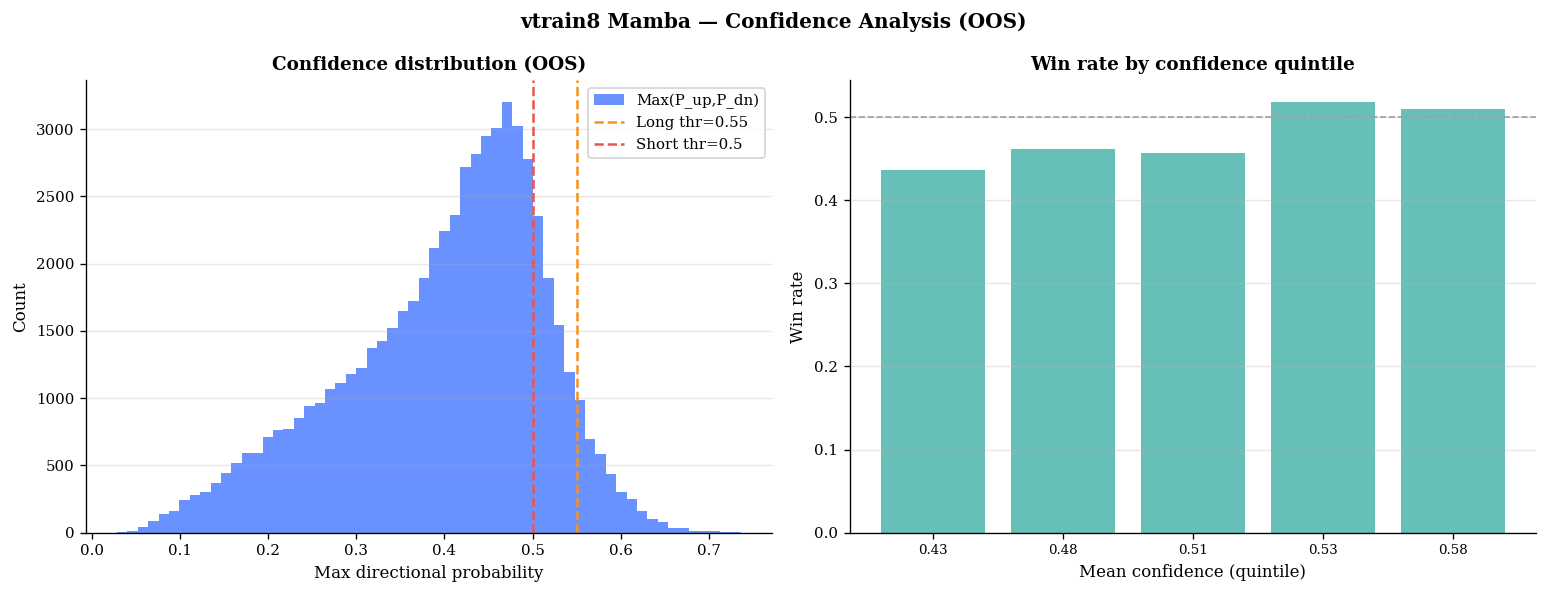

In [20]:
# Confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
conf_long  = np.maximum(p_up_oos, p_dn_oos)
ax.hist(conf_long, bins=60, color=BLUE, alpha=0.7, edgecolor='none', label='Max(P_up,P_dn)')
ax.axvline(best_params['long_threshold'],  color=ACCENT, lw=1.5,
           ls='--', label=f'Long thr={best_params["long_threshold"]}')
ax.axvline(best_params['short_threshold'], color=RED, lw=1.5,
           ls='--', label=f'Short thr={best_params["short_threshold"]}')
ax.set_xlabel('Max directional probability'); ax.set_ylabel('Count')
ax.set_title('Confidence distribution (OOS)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Win rate by confidence decile
ax = axes[1]
if len(tdf_oos) >= 20:
    entry_confs = []
    for _, row in tdf_oos.iterrows():
        bar = int(row['entry_bar'])
        if bar < len(p_up_oos):
            conf = p_up_oos[bar] if row['direction'] == 'long' else p_dn_oos[bar]
            entry_confs.append(conf)
        else:
            entry_confs.append(np.nan)
    tdf_oos2 = tdf_oos.copy()
    tdf_oos2['entry_conf'] = entry_confs
    tdf_oos2 = tdf_oos2.dropna(subset=['entry_conf'])
    if len(tdf_oos2) >= 10:
        tdf_oos2['conf_decile'] = pd.qcut(tdf_oos2['entry_conf'], q=5, labels=False,
                                           duplicates='drop')
        wr_by_conf = tdf_oos2.groupby('conf_decile').apply(
            lambda g: pd.Series({
                'win_rate': (g['pnl_pct'] > 0).mean(),
                'n_trades': len(g),
                'mean_conf': g['entry_conf'].mean(),
            })
        )
        ax.bar(range(len(wr_by_conf)), wr_by_conf['win_rate'], color=GREEN, alpha=0.7)
        ax.axhline(0.5, color=GREY, ls='--', lw=1)
        ax.set_xticks(range(len(wr_by_conf)))
        ax.set_xticklabels([f'{v:.2f}' for v in wr_by_conf['mean_conf']], fontsize=8)
        ax.set_xlabel('Mean confidence (quintile)'); ax.set_ylabel('Win rate')
        ax.set_title('Win rate by confidence quintile', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Insufficient trades for confidence analysis',
            ha='center', va='center', transform=ax.transAxes)

fig.suptitle('v8 Mamba — Confidence Analysis (OOS)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'mamba_confidence_analysis.png'); plt.show()


## Phase 4 — Test Set Evaluation

Retrain on full TrainVal, generate test probabilities, run backtest with best OOS params.
This is the final held-out evaluation — **data from 2024-11-10 onwards**.


In [21]:
# ── Retrain on full TrainVal ─────────────────────────────────────────────────
qt_final = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                                random_state=SEED)
qt_final.fit(X_tv)
X_tv_scaled   = qt_final.transform(X_tv).astype(np.float32)
X_test_scaled = qt_final.transform(X_test).astype(np.float32)

# Training sequences from full TrainVal
tv_idx = np.arange(N_TV)
X_tr_final, y_tr_final, _ = build_sequences(X_tv_scaled, y_tv, SEQ_LEN, tv_idx)
print(f'Final train sequences: {len(X_tr_final):,}')

# Held-out val: last 10% of TrainVal for early stopping (no test leak)
n_val_final = min(KFOLD_INTERNAL_VAL_H, int(0.10 * N_TV))
X_vf = X_tr_final[-n_val_final:]
y_vf = y_tr_final[-n_val_final:]
X_trf = X_tr_final[:-n_val_final]
y_trf = y_tr_final[:-n_val_final]

cw_final = compute_class_weights(y_trf).to(DEVICE)
model_final = MambaTimeSeriesClassifier(
    input_dim=X_trf.shape[2], d_model=D_MODEL, d_state=D_STATE,
    d_conv=D_CONV, expand=EXPAND, n_layers=N_MAMBA_LAYERS, dropout=DROPOUT,
).to(DEVICE)
opt_final = torch.optim.AdamW(model_final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sch_final = torch.optim.lr_scheduler.CosineAnnealingLR(opt_final, T_max=EPOCHS)
crit_final = nn.CrossEntropyLoss(weight=cw_final)

tr_ld_f = DataLoader(TensorDataset(torch.from_numpy(X_trf), torch.from_numpy(y_trf)),
                     batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
vl_ld_f = DataLoader(TensorDataset(torch.from_numpy(X_vf), torch.from_numpy(y_vf)),
                     batch_size=512, shuffle=False)

best_vl_f  = float('inf'); best_st_f = None; pat_f = 0
pbar = tqdm(range(EPOCHS), desc='Final model training', ncols=80)
for epoch in pbar:
    tr_l = train_one_epoch(model_final, tr_ld_f, opt_final, crit_final, DEVICE, GRAD_CLIP)
    vl_l = eval_loss(model_final, vl_ld_f, crit_final, DEVICE)
    sch_final.step()
    if vl_l < best_vl_f:
        best_vl_f = vl_l
        best_st_f = {k: v.cpu().clone() for k, v in model_final.state_dict().items()}
        pat_f = 0
    else:
        pat_f += 1
    pbar.set_postfix({'tr': f'{tr_l:.4f}', 'vl': f'{vl_l:.4f}', 'pat': pat_f})
    if pat_f >= PATIENCE:
        print(f'Early stop at epoch {epoch+1}'); break

model_final.load_state_dict(best_st_f)
print(f'Final model trained. Best val loss: {best_vl_f:.4f}')


Final train sequences: 61,071


Final model training:  19%|▏| 15/80 [19:03<1:22:33, 76.21s/it, tr=0.3185, vl=2.2

Early stop at epoch 16
Final model trained. Best val loss: 0.9801


In [22]:
# ── Test set inference ────────────────────────────────────────────────────────
N_TEST = len(test_df)
test_idx = np.arange(N_TEST)

# Need context: prepend last (SEQ_LEN-1) rows of TrainVal for sequence continuity
ctx_tv   = X_tv_scaled[-(SEQ_LEN - 1):]
X_ctx    = np.concatenate([ctx_tv, X_test_scaled], axis=0)  # (SEQ_LEN-1+N_TEST, F)
y_ctx    = np.concatenate([y_tv[-(SEQ_LEN - 1):], y_test])
idx_ctx  = np.arange(SEQ_LEN - 1, SEQ_LEN - 1 + N_TEST)    # positions in X_ctx for test rows

X_test_seq, y_test_seq, test_pos = build_sequences(X_ctx, y_ctx, SEQ_LEN, idx_ctx)
print(f'Test sequences: {len(X_test_seq):,}')

test_probs = predict_probs(model_final, X_test_seq, DEVICE)
p_up_test  = test_probs[:, 1].astype(np.float64)
p_dn_test  = test_probs[:, 0].astype(np.float64)

# Align test market arrays to valid sequence positions
valid_test_rows = [p - (SEQ_LEN - 1) for p in test_pos]  # back to test_df row index
c_test = test_close[valid_test_rows]; h_test = test_high[valid_test_rows]
l_test = test_low[valid_test_rows];   a_test = test_atr[valid_test_rows]
idx_test_valid = test_index[valid_test_rows]

y_test_valid = y_test[valid_test_rows]
auc_long_test  = roc_auc_score((y_test_valid == 1).astype(int), p_up_test)
auc_short_test = roc_auc_score((y_test_valid == 0).astype(int), p_dn_test)
print(f'Test AUC_Long  : {auc_long_test:.4f}')
print(f'Test AUC_Short : {auc_short_test:.4f}')

eq_test, tdf_test = run_backtest_v8(
    p_up_test, p_dn_test, c_test, h_test, l_test, a_test, best_params,
)
bh_test  = c_test / c_test[0]
min_len  = min(len(idx_test_valid), len(eq_test), len(bh_test))
eq_test  = eq_test[:min_len]
bh_test  = bh_test[:min_len]
dt_test  = idx_test_valid[:min_len]


Test sequences: 13,177
Test AUC_Long  : 0.5693
Test AUC_Short : 0.5503


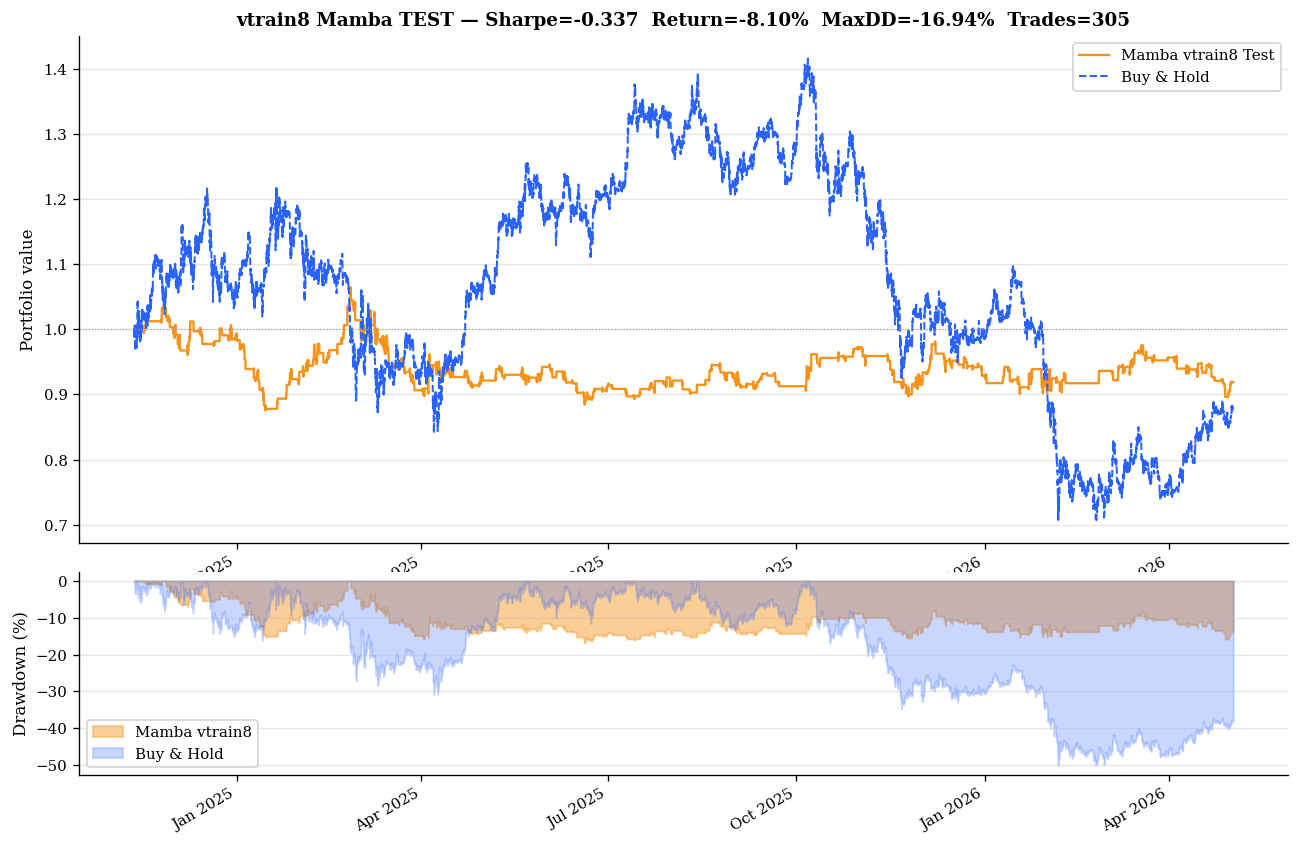

TEST | Sharpe=-0.337  Return=-8.10%  MaxDD=-16.94%  Trades=305  Fill=50.2%  WR=46.2%
      Long=17  Short=288  TP=79  SL=65  Conf=161


In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(dt_test, eq_test, color=ACCENT, lw=1.4, label='Mamba v8 Test')
ax.plot(dt_test, bh_test, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value'); ax.legend(); ax.grid(axis='y', alpha=0.3)

ret_test = np.log(np.maximum(eq_test[1:], 1e-12) / np.maximum(eq_test[:-1], 1e-12))
pk_test  = np.maximum.accumulate(eq_test)
sh_test  = ret_test.mean() / (ret_test.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)
mdd_test = ((eq_test - pk_test) / (pk_test + 1e-12)).min()
ax.set_title(
    f'v8 Mamba TEST — Sharpe={sh_test:.3f}  Return={eq_test[-1]-1:+.2%}  '
    f'MaxDD={mdd_test:.2%}  Trades={len(tdf_test)}',
    fontweight='bold',
)

ax = axes[1]
pk_b = np.maximum.accumulate(bh_test)
ax.fill_between(dt_test, (eq_test - pk_test) / (pk_test + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Mamba v8')
ax.fill_between(dt_test, (bh_test - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'mamba_backtest_results.png'); plt.show()

if len(tdf_test):
    fr_t = tdf_test.attrs['n_fills'] / max(tdf_test.attrs['n_signals'], 1)
    print(f'TEST | Sharpe={sh_test:.3f}  Return={eq_test[-1]-1:+.2%}  MaxDD={mdd_test:.2%}  '
          f'Trades={len(tdf_test)}  Fill={fr_t:.1%}  WR={(tdf_test["pnl_pct"]>0).mean():.1%}')
    print(f'      Long={int((tdf_test["direction"]=="long").sum())}  '
          f'Short={int((tdf_test["direction"]=="short").sum())}  '
          f'TP={int((tdf_test["reason"]=="tp").sum())}  '
          f'SL={int((tdf_test["reason"]=="sl").sum())}  '
          f'Conf={int((tdf_test["reason"]=="conf").sum())}')
else:
    print('No trades on test set.')


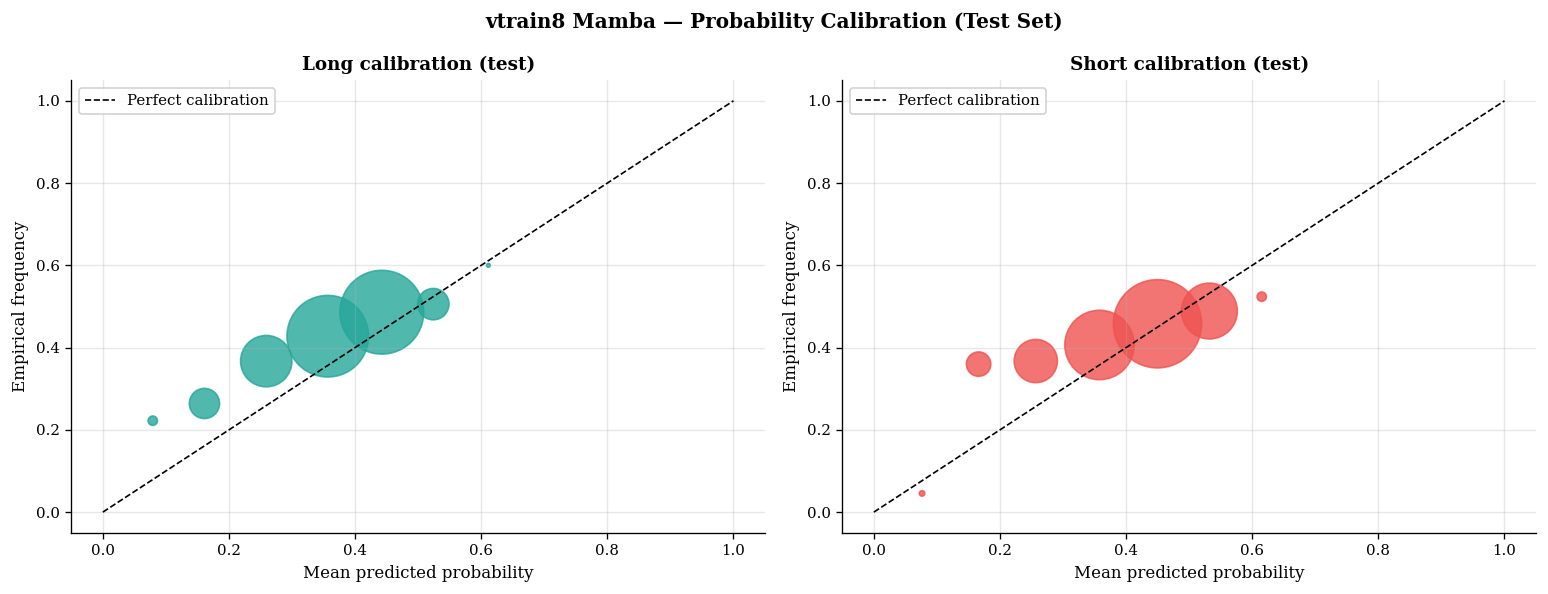

In [24]:
# Calibration: predicted probability vs empirical win rate
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, probs, labels, title, color in [
    (axes[0], p_up_test,  (y_test_valid == 1).astype(int), 'Long calibration (test)',  GREEN),
    (axes[1], p_dn_test,  (y_test_valid == 0).astype(int), 'Short calibration (test)', RED),
]:
    bins = np.linspace(0, 1, 11)
    bin_idx = np.digitize(probs, bins) - 1
    empirical, predicted, counts = [], [], []
    for b in range(len(bins) - 1):
        mask = bin_idx == b
        if mask.sum() >= 5:
            empirical.append(labels[mask].mean())
            predicted.append(probs[mask].mean())
            counts.append(mask.sum())
    if empirical:
        ax.scatter(predicted, empirical, s=[c/2 for c in counts], color=color, alpha=0.8)
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Empirical frequency')
        ax.set_title(title, fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('v8 Mamba — Probability Calibration (Test Set)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'mamba_calibration.png'); plt.show()


In [25]:
# Final summary table
summary_rows = [
    {
        'Stage':         'OOS K-Fold (TrainVal)',
        'Sharpe':        f'{sharpe:.3f}',
        'Return':        f'{eq_oos[-1]-1:+.2%}',
        'MaxDD':         f'{mdd:.2%}',
        'Trades':        int(len(tdf_oos)),
        'WR':            f'{(tdf_oos["pnl_pct"]>0).mean():.1%}' if len(tdf_oos) else 'N/A',
        'AUC Long':      f'{auc_long:.4f}',
        'AUC Short':     f'{auc_short:.4f}',
        'Model':         f'Mamba {N_MAMBA_LAYERS}L D{D_MODEL} S{D_STATE}',
        'Label':         f'TBM ±{TBM_ATR_MULT}×ATR {TBM_HORIZON}h',
        'Fees':          'Maker=0% Taker=0.05%',
        'Routing':       'Spot longs / Futures shorts',
        'v8 fix':        'Unfilled order cooldown',
    },
]
if len(tdf_test):
    fr_t = tdf_test.attrs['n_fills'] / max(tdf_test.attrs['n_signals'], 1)
    summary_rows.append({
        'Stage':         'Test (held-out)',
        'Sharpe':        f'{sh_test:.3f}',
        'Return':        f'{eq_test[-1]-1:+.2%}',
        'MaxDD':         f'{mdd_test:.2%}',
        'Trades':        int(len(tdf_test)),
        'WR':            f'{(tdf_test["pnl_pct"]>0).mean():.1%}',
        'AUC Long':      f'{auc_long_test:.4f}',
        'AUC Short':     f'{auc_short_test:.4f}',
        'Model':         f'Mamba {N_MAMBA_LAYERS}L D{D_MODEL} S{D_STATE}',
        'Label':         f'TBM ±{TBM_ATR_MULT}×ATR {TBM_HORIZON}h',
        'Fees':          'Maker=0% Taker=0.05%',
        'Routing':       'Spot longs / Futures shorts',
        'v8 fix':        'Unfilled order cooldown',
    })

summary_df = pd.DataFrame(summary_rows).T
print('\n── v8 Mamba Summary ──────────────────────────────────────────────────')
print(summary_df.to_string())
print('\nFigures saved:')
for fname in [
    'mamba_oos_prob_distribution.png', 'mamba_grid_distributions.png',
    'mamba_grid_sensitivity.png',      'mamba_oos_equity.png',
    'mamba_confidence_analysis.png',   'mamba_backtest_results.png',
    'mamba_calibration.png',
]:
    print(f'  {FIGURES_DIR / fname}')



── vtrain8 Mamba Summary ──────────────────────────────────────────────────
                                     0                            1
Stage            OOS K-Fold (TrainVal)              Test (held-out)
Sharpe                           0.602                       -0.337
Return                        +130.62%                       -8.10%
MaxDD                          -46.38%                      -16.94%
Trades                            1061                          305
WR                               47.7%                        46.2%
AUC Long                        0.5572                       0.5693
AUC Short                       0.5687                       0.5503
Model                  Mamba 2L D64 S8              Mamba 2L D64 S8
Label                 TBM ±2.0×ATR 24h             TBM ±2.0×ATR 24h
Fees              Maker=0% Taker=0.05%         Maker=0% Taker=0.05%
Routing    Spot longs / Futures shorts  Spot longs / Futures shorts
v8 fix         Unfilled order cooldown 